# Parameters

In [ ]:
from common.utils import (
    check_initial_sector_omega_ratio,
    omega_c,
    delta0_from_N_Gamma,
    Omega0_from_N_Gamma,
    default_three_phase_protocol,
    validated_mcwf_dt,
)

from pathlib import Path
import numpy as np
from quantum_trajectories.parser import MomentSeries

%reload_ext autoreload
%autoreload 2

seed = 1234
num_snapshots = 100


### Simulation

In [ ]:
import sys
import time

from common.utils import Omega_Gamma_from_cavity_parameters
from quantum_trajectories.state_helpers import (
    centered_sector_initial_coeffs,
    centered_group_resolved_sector_initial_coeffs,
)
from quantum_trajectories.ensamble_sim import run_trajectory_ensemble


# Run parameters
N=10
dN=0
N1=5
dt=1e-2
Gamma=1.0
ntraj=10
shifted_jump_operator=True
omega_1=0.7
n_processes=10

N_J = N // 2
N2 = N-N1

# Model and parameters
Omega_ratio = 0.4
Omega0 = Omega_ratio * omega_c(N_J, Gamma)
delta0 = 1

# protocol phases
phases = default_three_phase_protocol(
    T1=5.0,
    T2=500.0,
    T3=5.0,
    delta0=delta0,
    Omega0=Omega0,
)
moments = MomentSeries(phases=phases, num_snapshots=num_snapshots)

# sector coeff.
inhomogeneous_sector_coeffs = centered_group_resolved_sector_initial_coeffs(
    N,
    dN=dN,
    N1=N1,
    N2=N2,
    sector_distribution="binomial",
)

inhomogeneous_ratio_check = check_initial_sector_omega_ratio(
        inhomogeneous_sector_coeffs,
        Omega=max(abs(phase.omega) for phase in phases),
        Gamma=Gamma,
    )
if not inhomogeneous_ratio_check["is_valid"]:
    sys.exit(
        "Omega/Omega_c check not valid for inhomogeneous run: "
        f"Omega={inhomogeneous_ratio_check['omega']}, Omega_c={inhomogeneous_ratio_check['omega_c']}, "
        f"smallest Nj={inhomogeneous_ratio_check['min_nj']}, ratio={inhomogeneous_ratio_check['ratio']}"
    )

t0 = time.perf_counter()
inhomogeneous_ensemble = run_trajectory_ensemble(
    N=N,
    Gamma=Gamma,
    phases=phases,
    sector_coeffs=inhomogeneous_sector_coeffs,
    dt=dt,
    num_snapshots=num_snapshots,
    seed=seed,
    ntraj=ntraj,
    shifted_jump_operator=shifted_jump_operator,
    omega_1=omega_1,
    N1=N1,
    N2=N2,
    n_processes=n_processes,
    chunksize=1,
    verbose=True,
)
simulation_time = time.perf_counter() - t0

print("simulation runtime:", simulation_time)


Precompute: 0.02 seconds.
Pool startup: 10 processes in 0.30 seconds.


simulate trajectories: 100%|██████████| 10/10 [00:02<00:00,  3.55it/s]

Simulation step summary (avg per trajectory): total steps=51561.70, steps without precompute=576.70
simulation_time: 3.157624166997266


In [ ]:
from quantum_trajectories.j_moments import compute_ensemble_j_moments

t0 = time.perf_counter()
moments.J = compute_ensemble_j_moments(
    inhomogeneous_ensemble,
    n_processes=n_processes,
)
j_moment_time = time.perf_counter() - t0
print("j moment time:", j_moment_time)



compute_ensemble_j_moments: 100%|██████████| 10/10 [00:01<00:00,  7.74it/s]

j_moment_time: 1.4266031660081353


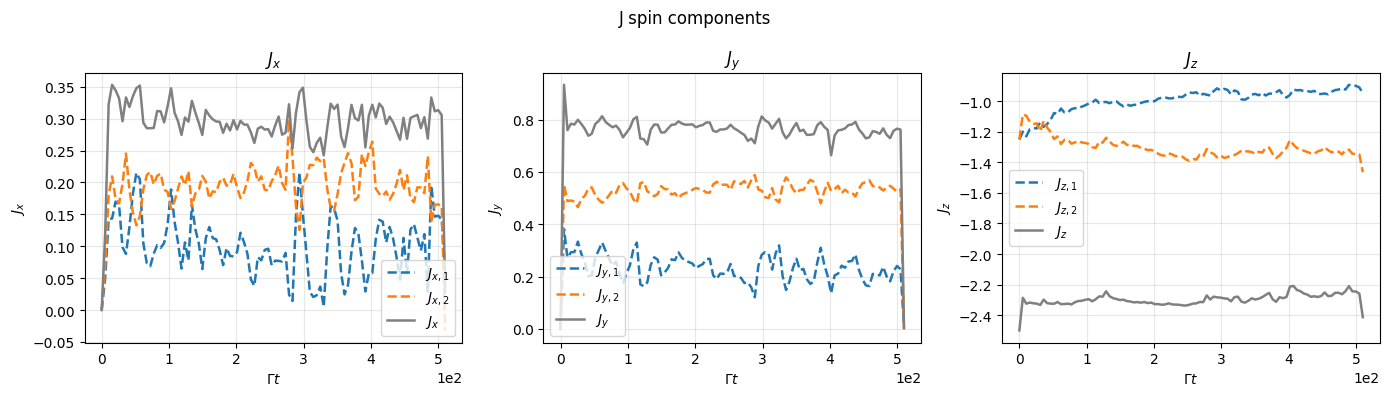

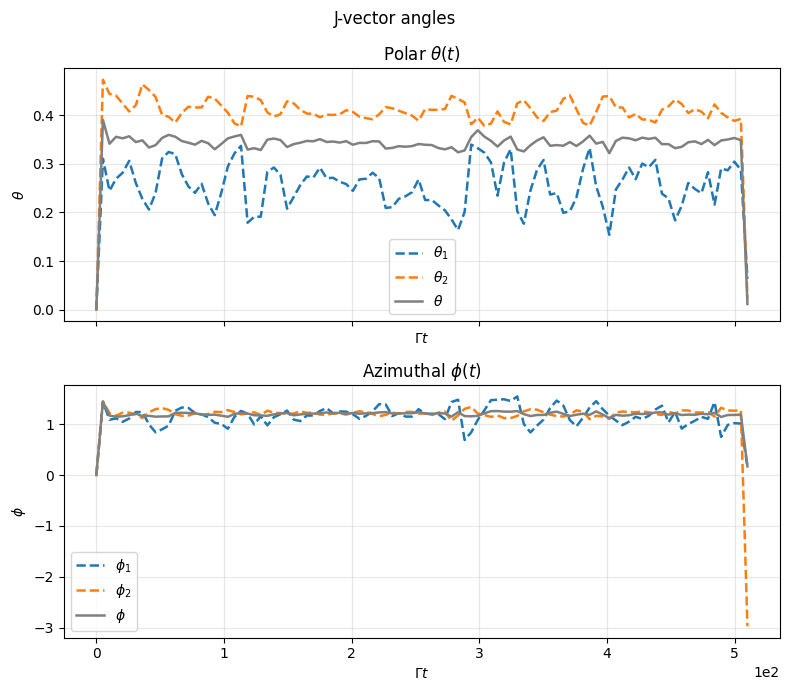

In [16]:
from quantum_trajectories.plotting_j_moments import (
    plot_j_spin_components,
    plot_j_angles,
)

output_dir = Path("output")
fig, axes = plot_j_spin_components(
    moments.J,
    # output_path = output_dir / "inhomogeneous_nj1_zero_vs_homogeneous.png",
    # label="run 1",
    )
fig, axes = plot_j_angles(
    moments.J,
)